In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
from scipy import stats
import statistics
import sys

# from scipy.stats import distributions
# import similaritymeasures

In [3]:
#   Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '4'
apperture = '20'
source = '33'

data = f'{path}{date}/export_txt'

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_AP0{apperture}_SRC{source}.txt',skiprows=1)
data2 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

#
time = data1[:,0]
mag  = data1[:,2]
mag_error = data1[:,3]
#
time_pol = data2[:,0]
circ_pol = data2[:,8]
circ_pol_error = data2[:,9]

In [5]:
# convert magnitude to flux
flux = 10**(-0.4*(mag-12))
circ_pol = circ_pol* 0.01
#print(flux)
#print(len(mag))
#print(len(flux))
#print(len(circ_pol))

In [7]:
# criterio
delta_time = np.diff(time)
#print(time)
#print(delta_time)
moda = statistics.mode(delta_time)
#print(moda)
criterio = (moda*8*1.1)/2
#print(criterio)
#####   avarage  #####
#print(time)
#condicao = False
flux_pol = circ_pol*0.0
flux_ave = circ_pol*0.0
#
for i,x in enumerate(time_pol):
    print(i,x)
    indice = []
    print(x-criterio,x+criterio)
    for j,y in enumerate(time):
           # print(j)
           #for f,z in enumerate(flux):
           if (y > (x-criterio)) and (y < (x+criterio)):
                  indice.append(j)
           #avefluxo.append(np.average(z))
    print(indice)
    # print(flux[indice])
    flux_ave[i]=np.average(flux[indice])
flux_pol=circ_pol*flux_ave
#print(avefluxo,circ_pol[i],flux_pol[i])
#sys.exit("Sai!")

0 2460863.4295797646
2460863.427919394 2460863.4312401353
[0, 1, 2, 3, 4, 5, 6, 7, 8]
1 2460863.429957696
2460863.428297325 2460863.4316180665
[1, 2, 3, 4, 5, 6, 7, 8, 9]
2 2460863.430334988
2460863.4286746173 2460863.431995359
[2, 3, 4, 5, 6, 7, 8, 9, 10]
3 2460863.4307129527
2460863.429052582 2460863.4323733235
[3, 4, 5, 6, 7, 8, 9, 10, 11]
4 2460863.4310904955
2460863.429430125 2460863.4327508663
[4, 5, 6, 7, 8, 9, 10, 11, 12]
5 2460863.431467071
2460863.4298067004 2460863.433127442
[5, 6, 7, 8, 9, 10, 11, 12, 13]
6 2460863.43184407
2460863.4301836994 2460863.433504441
[6, 7, 8, 9, 10, 11, 12, 13, 14]
7 2460863.4322221326
2460863.430561762 2460863.4338825033
[7, 8, 9, 10, 11, 12, 13, 14, 15]
8 2460863.4325998486
2460863.430939478 2460863.4342602193
[8, 9, 10, 11, 12, 13, 14, 15, 16]
9 2460863.432980111
2460863.43131974 2460863.4346404816
[9, 10, 11, 12, 13, 14, 15, 16, 17]
10 2460863.433357972
2460863.4316976015 2460863.435018343
[10, 11, 12, 13, 14, 15, 16, 17, 18]
11 2460863.43373

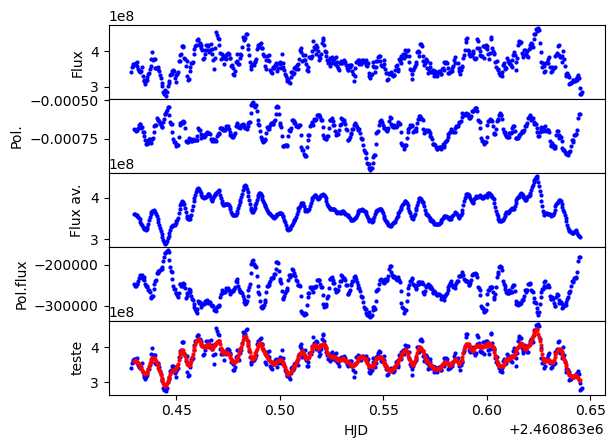

In [9]:
# Plot
plt.close('all')
#
#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(5, sharex=True)
f.subplots_adjust(hspace=0.0)
#f.align_ylabels(ax[0:1])
#
ax[0].plot(time,flux,'b.',markersize=4)
ax[0].set_ylabel('Flux')
# ax[0].set_xlim(52455.2,52455.4)
#
ax[1].plot(time_pol,circ_pol,'b.',markersize=4)
ax[1].set_ylabel('Pol.')
#
ax[2].plot(time_pol,flux_ave,'b.',markersize=4)
ax[2].set_ylabel('Flux av.')
#
ax[3].plot(time_pol,flux_pol,'b.',markersize=4)
ax[3].set_ylabel('Pol.flux')
#
ax[4].plot(time,flux,'b.',markersize=4)
ax[4].plot(time_pol,flux_ave,'r.',markersize=4)
ax[4].set_ylabel('teste')
ax[4].set_xlabel('HJD')
#
plt.show()